# Startup Investment Outcome — Imbalanced Data (Binary Classification)

**Configuration:** Set `PROBLEM = "closed"` or `"acquired"` in the **Config cell** (cell 2 below) to switch between binary targets.

**Input:** `data/train_processed.csv`, `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Diagnose class imbalance and evaluate resampling strategies for a **binary** classification problem using a lightweight XGBoost baseline.  
**Note:** All resampling is applied **only to the training set**. Validation and test sets remain untouched.

Each section ends with a **→ Modeling Decision** box.

## 0. Imports & Setup

In [2]:
!pip install imblearn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Change PROBLEM to switch between binary classification tasks:
#   "closed"   → predicts: is the startup closed? (status_code == 0 vs rest)
#   "acquired" → predicts: is the startup acquired? (status_code == 2 vs rest)

PROBLEM = "acquired"   # <── change this

# Everything below is derived automatically
if PROBLEM == "closed":
    TARGET_CLASS_CODE = 0
    STATUS_MAP        = {0: 'not_closed', 1: 'closed'}
    STATUS_NAMES      = ['not_closed', 'closed']
    RESAMPLED_OUT     = "data/train_resampled_closed.csv"
elif PROBLEM == "acquired":
    TARGET_CLASS_CODE = 2
    STATUS_MAP        = {0: 'not_acquired', 1: 'acquired'}
    STATUS_NAMES      = ['not_acquired', 'acquired']
    RESAMPLED_OUT     = "data/train_resampled_acquired.csv"
else:
    raise ValueError(f"PROBLEM must be 'closed' or 'acquired', got: '{PROBLEM}'")

# Metric used to select the best resampling technique (Sections 6, 8, 10, 11)
# Valid choices — must be a column name returned by classification_metrics():
#   'Macro F1'              — equal weight to both classes (recommended default)
#   'Weighted F1'           — weight by class frequency
#   'Accuracy'              — raw accuracy
#   f'F1 {STATUS_NAMES[1]}' — F1 of the positive (minority) class only
EVAL_METRIC = 'F1 acquired'   # <── change this

print(f"Problem      : {PROBLEM}")
print(f"Target class : {TARGET_CLASS_CODE}  ({STATUS_NAMES[1]})")
print(f"Class names  : {STATUS_NAMES}")
print(f"Output file  : {RESAMPLED_OUT}")
print(f"Eval metric  : {EVAL_METRIC}")

Problem      : closed
Target class : 0  (closed)
Class names  : ['not_closed', 'closed']
Output file  : data/train_resampled_closed.csv
Eval metric  : F1 closed


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, roc_curve, auc, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

# STATUS_MAP, STATUS_NAMES are set in the Config cell above
COLORS       = ['#FF5722', '#2196F3']
RANDOM_STATE = 42

## 1. Load Processed Data

In [5]:
train = pd.read_csv('data/train_processed.csv')
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# Create binary target: 1 = target class, 0 = all others
for df in [train, val, test]:
    df['status_code'] = (df['status_code'] == TARGET_CLASS_CODE).astype(int)

X_train = train.drop(columns=['status_code', 'status_code'])
y_train = train['status_code']

X_val = val.drop(columns=['status_code', 'status_code'])
y_val = val['status_code']

X_test = test.drop(columns=['status_code', 'status_code'])
y_test = test['status_code']

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nBinary class distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>12s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

Train: (27860, 51)  |  Val: (5971, 51)  |  Test: (5971, 51)

Binary class distribution (train):
  0 (  not_closed): 26,350  (94.6%)
  1 (      closed): 1,510  (5.4%)


## 2. Class Imbalance Diagnosis

Training set class distribution:
  0 (  not_closed): 26,350  (94.6%)
  1 (      closed): 1,510  (5.4%)


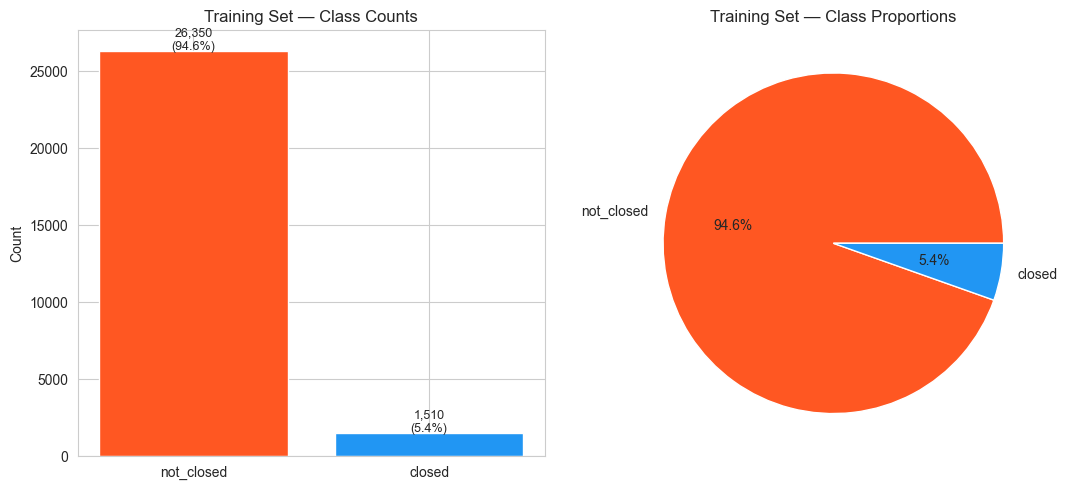


Imbalance ratio (majority / minority): 17.5x


In [6]:
counts = y_train.value_counts().sort_index()
pct    = (counts / len(y_train) * 100).round(1)

print("Training set class distribution:")
for k in counts.index:
    print(f"  {k} ({STATUS_MAP[k]:>12s}): {counts[k]:,}  ({pct[k]}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar([STATUS_MAP[k] for k in counts.index], counts.values, color=COLORS)
axes[0].set_title('Training Set — Class Counts')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({p}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=[STATUS_MAP[k] for k in counts.index],
            autopct='%1.1f%%', colors=COLORS)
axes[1].set_title('Training Set — Class Proportions')

plt.tight_layout()
plt.show()

majority = counts.max()
minority = counts.min()
print(f"\nImbalance ratio (majority / minority): {majority / minority:.1f}x")

> **→ Modeling Decision:** The dataset has significant class imbalance (operating >> acquired > closed).  
> We will test four resampling techniques against a baseline and select the best strategy based on **macro F1-score** on the **validation set**.


## 3. Evaluation Helper

In [7]:
def classification_metrics(y_true, y_pred, technique_name=''):
    """Return a metrics dict for binary classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1])
    return {
        'Technique':                 technique_name,
        'Accuracy':                  accuracy_score(y_true, y_pred),
        'Macro F1':                  f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':               f1_score(y_true, y_pred, average='weighted'),
        f'F1 {STATUS_NAMES[0]}':     per_class[0],
        f'F1 {STATUS_NAMES[1]}':     per_class[1],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 4. Baseline Model (No Resampling)

We use a lightweight XGBoost as our probe model throughout this notebook — same model family we expect to use in `05_Modeling.ipynb`.


Baseline — Validation Set
              precision    recall  f1-score   support

  not_closed       0.95      1.00      0.97      5647
      closed       0.28      0.02      0.03       324

    accuracy                           0.94      5971
   macro avg       0.61      0.51      0.50      5971
weighted avg       0.91      0.94      0.92      5971



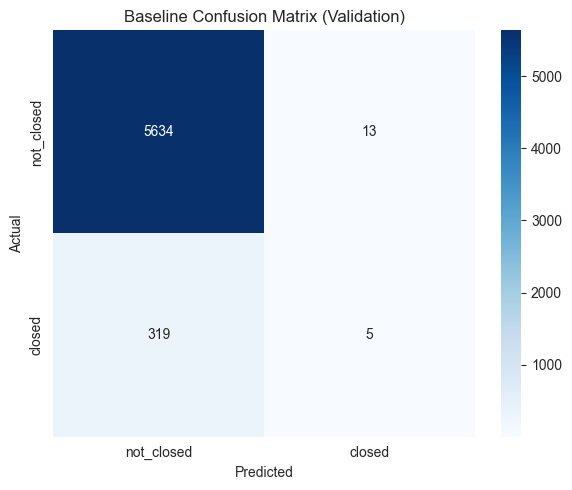

In [8]:
X_train = train.drop(columns=['status_code', 'status_code', 'geo_cluster'], errors='ignore')
X_val   = val.drop(columns=['status_code', 'status_code', 'geo_cluster'], errors='ignore')
X_test  = test.drop(columns=['status_code', 'status_code', 'geo_cluster'], errors='ignore')

baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    objective='binary:logistic',
    eval_metric='logloss',
    verbosity=0
)
baseline_model.fit(X_train, y_train)

y_pred_baseline_val = baseline_model.predict(X_val)

print("Baseline — Validation Set")
print(classification_report(y_val, y_pred_baseline_val, target_names=STATUS_NAMES))
plot_confusion_matrix(y_val, y_pred_baseline_val, 'Baseline Confusion Matrix (Validation)')

## 5. Resampling Techniques

We apply four standard imbalanced-learning strategies **to the training set only**, then evaluate each on the untouched validation set.

| Technique | Idea |
|-----------|------|
| **ROS** — Random Over-Sampling | Duplicate minority samples randomly |
| **RUS** — Random Under-Sampling | Drop majority samples randomly |
| **SMOTE** | Synthesise new minority samples between nearest neighbours |
| **SMOTETomek** | SMOTE + remove borderline Tomek pairs |


In [9]:
techniques = {
    'ROS':        RandomOverSampler(random_state=RANDOM_STATE),
    'RUS':        RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTE':      SMOTE(random_state=RANDOM_STATE),
    'SMOTETomek': SMOTETomek(random_state=RANDOM_STATE),
}


### 5.1 Class Distribution After Resampling

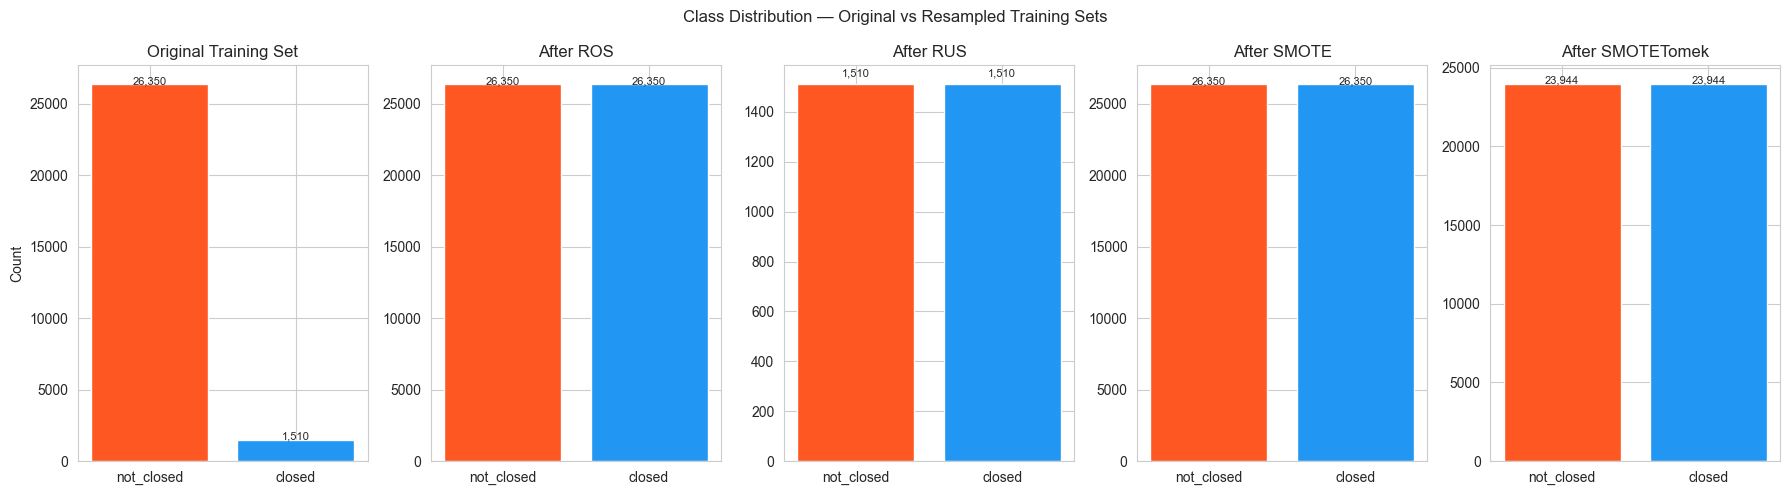

In [10]:
fig, axes = plt.subplots(1, len(techniques) + 1, figsize=(18, 5))

# Original
orig_counts = y_train.value_counts().sort_index()
axes[0].bar([STATUS_MAP[k] for k in orig_counts.index], orig_counts.values, color=COLORS)
axes[0].set_title('Original Training Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(orig_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

for ax, (name, technique) in zip(axes[1:], techniques.items()):
    X_res, y_res = technique.fit_resample(X_train, y_train)
    res_counts = pd.Series(y_res).value_counts().sort_index()
    ax.bar([STATUS_MAP[k] for k in res_counts.index], res_counts.values, color=COLORS)
    ax.set_title(f'After {name}')
    for i, v in enumerate(res_counts.values):
        ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Class Distribution — Original vs Resampled Training Sets', fontsize=12)
plt.tight_layout()
plt.show()


### 5.2 Feature-Space Visualisation (log_funding_total_usd vs log_venture)

Two of the most informative funding features — visualised before and after resampling to see the synthetic / dropped points.


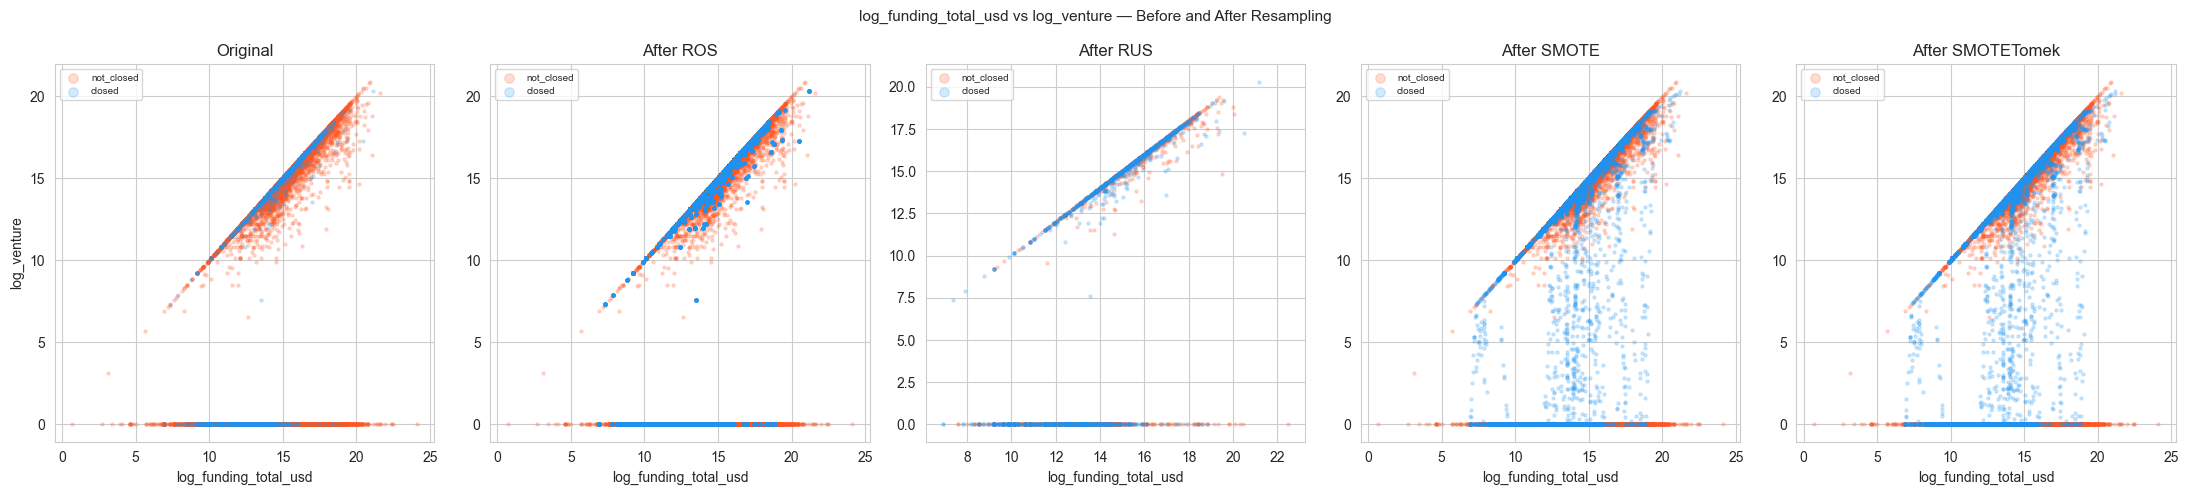

In [11]:
feat_x, feat_y = 'log_funding_total_usd', 'log_venture'

fig, axes = plt.subplots(1, len(techniques) + 1, figsize=(22, 5))

# Original
for cls, color, label in zip([0, 1], COLORS, STATUS_NAMES):
    mask = y_train == cls
    axes[0].scatter(X_train.loc[mask, feat_x], X_train.loc[mask, feat_y],
                    alpha=0.2, s=5, color=color, label=label)
axes[0].set_title('Original')
axes[0].set_xlabel(feat_x); axes[0].set_ylabel(feat_y)
axes[0].legend(markerscale=3, fontsize=7)

for ax, (name, technique) in zip(axes[1:], techniques.items()):
    X_res, y_res = technique.fit_resample(X_train, y_train)
    X_res_df = pd.DataFrame(X_res, columns=X_train.columns)
    y_res_s  = pd.Series(y_res)
    for cls, color, label in zip([0, 1], COLORS, STATUS_NAMES):
        mask = y_res_s == cls
        ax.scatter(X_res_df.loc[mask, feat_x], X_res_df.loc[mask, feat_y],
                   alpha=0.2, s=5, color=color, label=label)
    ax.set_title(f'After {name}')
    ax.set_xlabel(feat_x)
    ax.legend(markerscale=3, fontsize=7)

plt.suptitle(f'{feat_x} vs {feat_y} — Before and After Resampling', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Performance Comparison on Validation Set

In [12]:
all_results = []

# Baseline
all_results.append(classification_metrics(y_val, y_pred_baseline_val, 'Baseline (no resampling)'))

# Resampling techniques
for name, technique in techniques.items():
    X_res, y_res = technique.fit_resample(X_train, y_train)
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, objective='binary:logistic',
        eval_metric='logloss', verbosity=0
    )
    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)
    all_results.append(classification_metrics(y_val, y_pred, name))

results_df = pd.DataFrame(all_results).set_index('Technique')
display(results_df.round(4).sort_values(EVAL_METRIC, ascending=False))

,Accuracy,Macro F1,Weighted F1,F1 not_closed,F1 closed
Technique,,,,,
ROS,0.7682,0.5526,0.8295,0.8632,0.2421
RUS,0.7036,0.5163,0.7846,0.8173,0.2154
SMOTE,0.9332,0.5608,0.9213,0.9652,0.1564
SMOTETomek,0.9342,0.5603,0.9218,0.9658,0.1548
Baseline (no resampling),0.9444,0.5003,0.9203,0.9714,0.0292


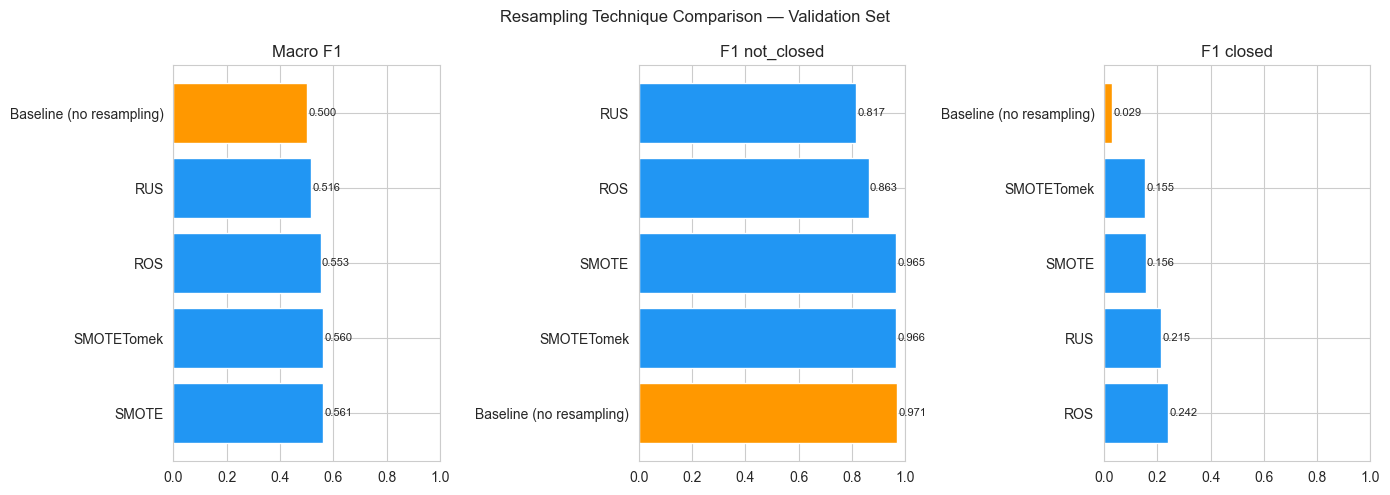

In [13]:
metrics_to_plot = ['Macro F1', f'F1 {STATUS_NAMES[0]}', f'F1 {STATUS_NAMES[1]}']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].sort_values(ascending=False)
    bar_colors = ['#FF9800' if t == 'Baseline (no resampling)' else '#2196F3' for t in vals.index]
    ax.barh(vals.index, vals.values, color=bar_colors)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Resampling Technique Comparison — Validation Set', fontsize=12)
plt.tight_layout()
plt.show()

> **→ Modeling Decision:** The table and chart above identify the best resampling strategy for this binary problem.  
> Use **Macro F1** as the primary criterion — it treats both classes equally, penalising poor performance on the minority class.

## 7. ROC Curve (Validation Set)

Single binary ROC curve comparing all resampling techniques.

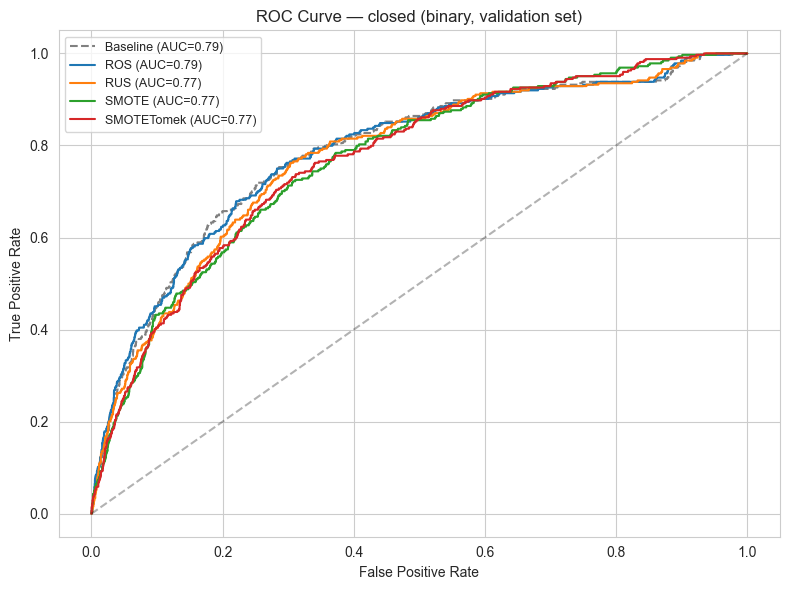

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Baseline
proba_baseline = baseline_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, proba_baseline)
ax.plot(fpr, tpr, linestyle='--', label=f'Baseline (AUC={auc(fpr,tpr):.2f})', color='grey')

for name, technique in techniques.items():
    X_res, y_res = technique.fit_resample(X_train, y_train)
    m = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                      random_state=RANDOM_STATE, objective='binary:logistic',
                      eval_metric='logloss', verbosity=0)
    m.fit(X_res, y_res)
    proba = m.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title(f'ROC Curve — {STATUS_NAMES[1]} (binary, validation set)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Decision Threshold Tuning (Validation Set)

For binary classification the threshold controls the trade-off between precision and recall on the positive class.  
A prediction is `1` when `P(positive) >= threshold`; otherwise `0`.

We sweep the threshold and report **Macro F1** on the validation set.

Best resampling technique (by F1 closed): ROS


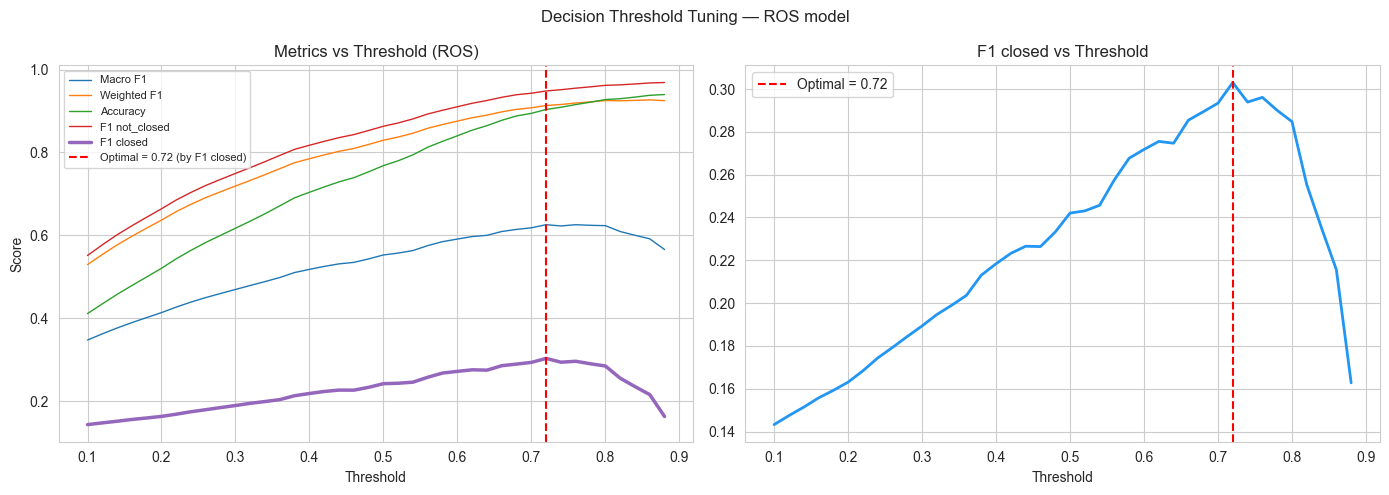


Optimal threshold (max F1 closed on val): 0.72
           Technique  Accuracy  Macro F1  Weighted F1  F1 not_closed  F1 closed
Threshold                                                                      
0.72            0.72    0.9037    0.6257       0.9133         0.9483     0.3030
0.76            0.76    0.9156    0.6256       0.9193         0.9551     0.2961
0.74            0.74    0.9091    0.6226       0.9157         0.9514     0.2939
0.70            0.70    0.8943    0.6181       0.9076         0.9429     0.2934
0.78            0.78    0.9213    0.6242       0.9221         0.9583     0.2900


In [15]:
# Use the best resampling technique found in Section 6
best_technique_name = results_df[EVAL_METRIC].idxmax()
print(f"Best resampling technique (by {EVAL_METRIC}): {best_technique_name}")

best_technique = techniques[best_technique_name] if best_technique_name in techniques else None

if best_technique is not None:
    X_res_best, y_res_best = best_technique.fit_resample(X_train, y_train)
    best_model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, objective='binary:logistic',
        eval_metric='logloss', verbosity=0
    )
    best_model.fit(X_res_best, y_res_best)
else:
    best_model = baseline_model

y_proba_val = best_model.predict_proba(X_val)[:, 1]  # P(positive class)

thresholds = np.arange(0.10, 0.90, 0.02)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    row = classification_metrics(y_val, y_pred_t, round(t, 2))
    row['Threshold'] = round(t, 2)
    threshold_results.append(row)

threshold_df = pd.DataFrame(threshold_results).set_index('Threshold')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all metrics vs threshold
for col in ['Macro F1', 'Weighted F1', 'Accuracy',
            f'F1 {STATUS_NAMES[0]}', f'F1 {STATUS_NAMES[1]}']:
    if col in threshold_df.columns:
        lw = 2.5 if col == EVAL_METRIC else 1.0
        axes[0].plot(threshold_df.index, threshold_df[col], label=col, linewidth=lw)

optimal_t = threshold_df[EVAL_METRIC].idxmax()
axes[0].axvline(optimal_t, color='red', linestyle='--',
                label=f'Optimal = {optimal_t} (by {EVAL_METRIC})')
axes[0].set_title(f'Metrics vs Threshold ({best_technique_name})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Right: selected EVAL_METRIC only
axes[1].plot(threshold_df.index, threshold_df[EVAL_METRIC], color='#2196F3', linewidth=2)
axes[1].axvline(optimal_t, color='red', linestyle='--', label=f'Optimal = {optimal_t}')
axes[1].set_title(f'{EVAL_METRIC} vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'Decision Threshold Tuning — {best_technique_name} model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold (max {EVAL_METRIC} on val): {optimal_t}")
print(threshold_df.sort_values(EVAL_METRIC, ascending=False).head(5).round(4).to_string())

> **Note:** Per the course notebook, threshold tuning is performed on the **validation set** — not the test set — so test metrics remain unbiased.


## 9. Class Weights (Alternative to Resampling)

XGBoost supports `sample_weight` to up-weight minority class samples without physically resampling the data.


XGBoost + Balanced Class Weights — Validation Set
              precision    recall  f1-score   support

  not_closed       0.98      0.78      0.86      5647
      closed       0.14      0.66      0.24       324

    accuracy                           0.77      5971
   macro avg       0.56      0.72      0.55      5971
weighted avg       0.93      0.77      0.83      5971



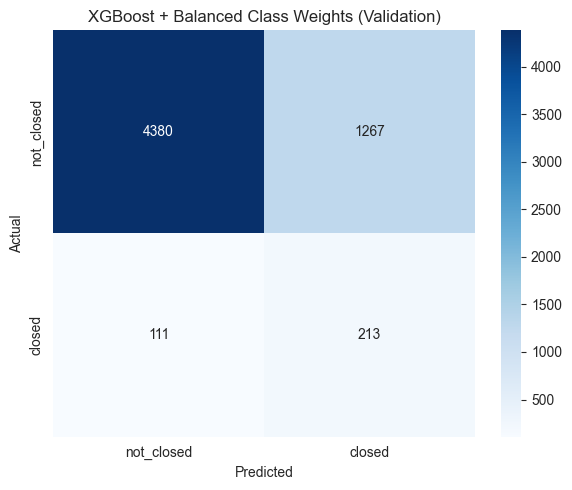

In [16]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_weighted = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, objective='binary:logistic',
    eval_metric='logloss', verbosity=0
)
model_weighted.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_weighted = model_weighted.predict(X_val)

print("XGBoost + Balanced Class Weights — Validation Set")
print(classification_report(y_val, y_pred_weighted, target_names=STATUS_NAMES))
plot_confusion_matrix(y_val, y_pred_weighted, 'XGBoost + Balanced Class Weights (Validation)')

## 10. Full Technique Comparison

,Accuracy,Macro F1,Weighted F1,F1 not_closed,F1 closed
Technique,,,,,
ROS,0.7682,0.5526,0.8295,0.8632,0.2421
XGBoost + Class Weights,0.7692,0.5501,0.8300,0.8641,0.2361
RUS,0.7036,0.5163,0.7846,0.8173,0.2154
SMOTE,0.9332,0.5608,0.9213,0.9652,0.1564
SMOTETomek,0.9342,0.5603,0.9218,0.9658,0.1548
Baseline (no resampling),0.9444,0.5003,0.9203,0.9714,0.0292


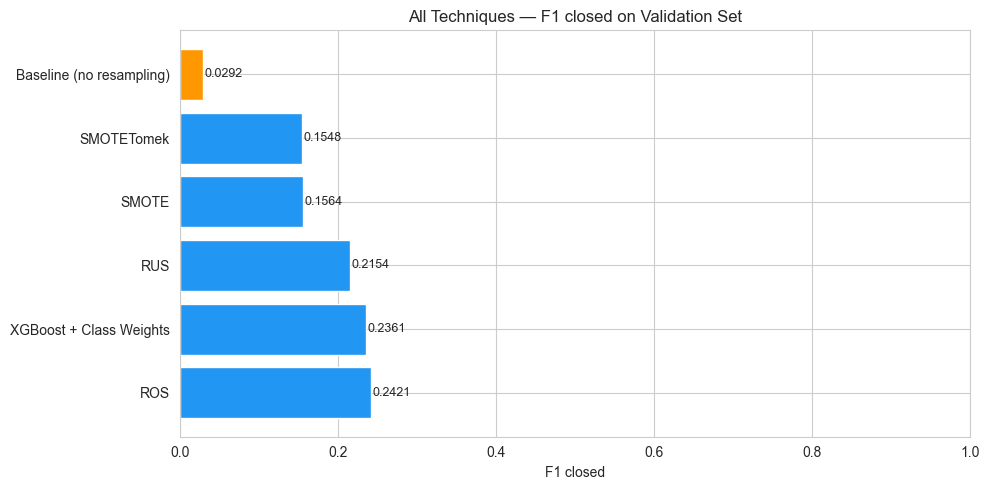

In [17]:
weighted_metrics = classification_metrics(y_val, y_pred_weighted, 'XGBoost + Class Weights')

final_results = results_df.reset_index().copy()
final_results = pd.concat([final_results, pd.DataFrame([weighted_metrics])], ignore_index=True)
final_results = final_results.set_index('Technique').sort_values(EVAL_METRIC, ascending=False)

display(final_results.round(4))

plt.figure(figsize=(10, 5))
colors_bar = ['#FF9800' if 'Baseline' in t else '#2196F3' for t in final_results.index]
bars = plt.barh(final_results.index, final_results[EVAL_METRIC], color=colors_bar)
for bar, v in zip(bars, final_results[EVAL_METRIC]):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.title(f'All Techniques — {EVAL_METRIC} on Validation Set')
plt.xlabel(EVAL_METRIC)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 11. Final Decision & Export

Based on the comparison above, select the best strategy and apply it to generate the final resampled training set for `07_Feature_Selection_n_Modeling_Binary.ipynb`.

1st: ROS   (F1 closed = 0.2421)
2nd: XGBoost + Class Weights (F1 closed = 0.2361)


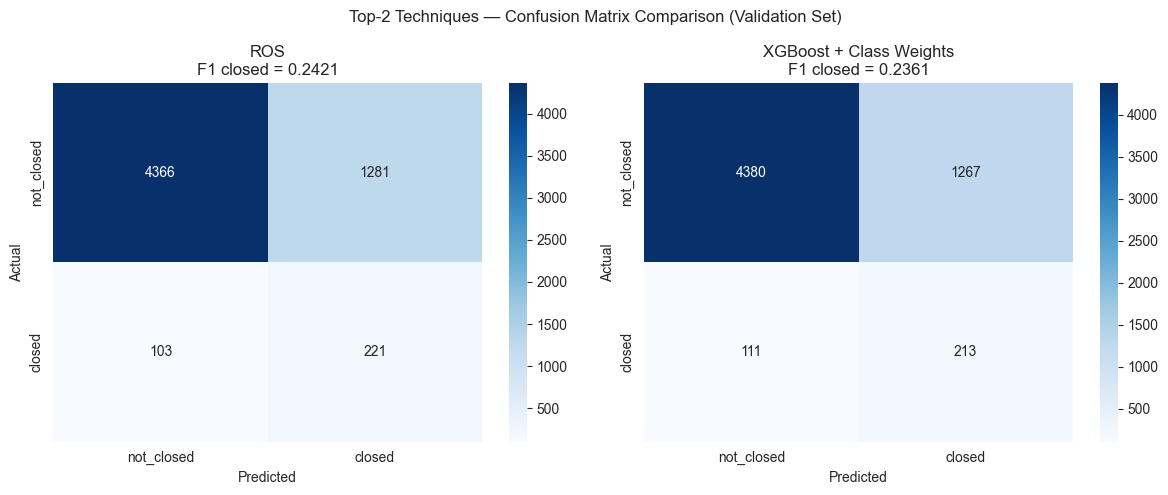

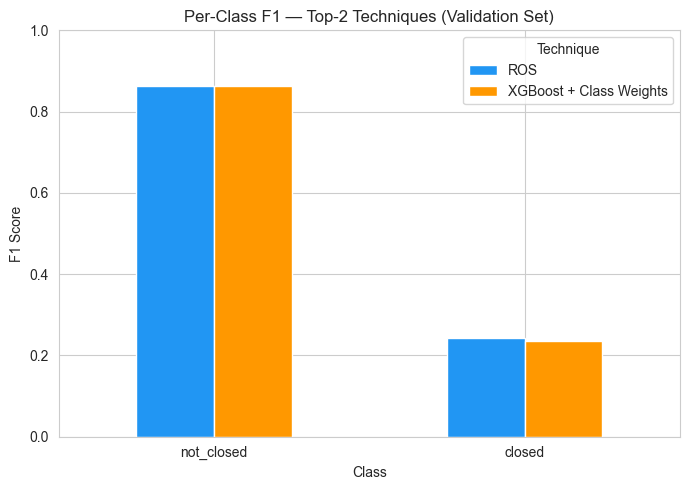


───────────────────────────────────────────────────────
 ROS
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  not_closed       0.98      0.77      0.86      5647
      closed       0.15      0.68      0.24       324

    accuracy                           0.77      5971
   macro avg       0.56      0.73      0.55      5971
weighted avg       0.93      0.77      0.83      5971


───────────────────────────────────────────────────────
 XGBoost + Class Weights
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  not_closed       0.98      0.78      0.86      5647
      closed       0.14      0.66      0.24       324

    accuracy                           0.77      5971
   macro avg       0.56      0.72      0.55      5971
weighted avg       0.93      0.77      0.83      5971


Resampled training set (ROS): (52700, 50)

Final class distribution:
  0 (  not_closed): 

In [18]:
import os

# ── Pick the best and 2nd best techniques ─────────────────────────────────
ranked = final_results[EVAL_METRIC].sort_values(ascending=False)
best_name   = ranked.index[0]
second_name = ranked.index[1]

print(f"1st: {best_name}   ({EVAL_METRIC} = {ranked.iloc[0]:.4f})")
print(f"2nd: {second_name} ({EVAL_METRIC} = {ranked.iloc[1]:.4f})")

def build_model(name):
    if name in techniques:
        X_res, y_res = techniques[name].fit_resample(X_train, y_train)
        m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            random_state=RANDOM_STATE, objective='binary:logistic',
            eval_metric='logloss', verbosity=0
        )
        m.fit(X_res, y_res)
    elif 'Class Weights' in name:
        m = model_weighted
    else:
        m = baseline_model
    return m

best_model   = build_model(best_name)
second_model = build_model(second_name)

y_pred_best   = best_model.predict(X_val)
y_pred_second = second_model.predict(X_val)

# ── Side-by-side confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, name in zip(axes,
                             [y_pred_best, y_pred_second],
                             [best_name,   second_name]):
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    score = final_results.loc[name, EVAL_METRIC]
    ax.set_title(f'{name}\n{EVAL_METRIC} = {score:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Top-2 Techniques — Confusion Matrix Comparison (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Per-class F1 comparison ────────────────────────────────────────────────
compare_df = pd.DataFrame({
    best_name:   f1_score(y_val, y_pred_best,   average=None, labels=[0, 1]),
    second_name: f1_score(y_val, y_pred_second, average=None, labels=[0, 1]),
}, index=STATUS_NAMES)

compare_df.plot(kind='bar', figsize=(7, 5), color=['#2196F3', '#FF9800'], edgecolor='white')
plt.title('Per-Class F1 — Top-2 Techniques (Validation Set)')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

for y_pred, name in [(y_pred_best, best_name), (y_pred_second, second_name)]:
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    print(classification_report(y_val, y_pred, target_names=STATUS_NAMES))

# ── Save resampled training set ────────────────────────────────────────────
if best_name in techniques:
    X_train_final, y_train_final = techniques[best_name].fit_resample(X_train, y_train)
    X_train_final = pd.DataFrame(X_train_final, columns=X_train.columns)
    y_train_final = pd.Series(y_train_final, name='status_code')
    print(f"\nResampled training set ({best_name}): {X_train_final.shape}")
else:
    X_train_final = X_train.copy()
    y_train_final = y_train.rename('status_code')
    print(f"\nNo physical resampling — training set unchanged: {X_train_final.shape}")

print("\nFinal class distribution:")
for k, cnt in y_train_final.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>12s}): {cnt:,}  ({cnt/len(y_train_final)*100:.1f}%)")

os.makedirs('data', exist_ok=True)
out = X_train_final.copy()
out['status_code'] = y_train_final.values
out.to_csv(RESAMPLED_OUT, index=False)
print(f"\nSaved → {RESAMPLED_OUT}")
print("Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.")

In [19]:
import os

# ── Pick the best technique ────────────────────────────────────────────────
best_name = final_results[EVAL_METRIC].idxmax()
print(f"Best technique: {best_name}  ({EVAL_METRIC} = {final_results.loc[best_name, EVAL_METRIC]:.4f})")

if best_name in techniques:
    X_train_final, y_train_final = techniques[best_name].fit_resample(X_train, y_train)
    X_train_final = pd.DataFrame(X_train_final, columns=X_train.columns)
    y_train_final = pd.Series(y_train_final, name='status_code')
    print(f"Resampled training set: {X_train_final.shape}")
elif 'Class Weights' in best_name:
    X_train_final = X_train.copy()
    y_train_final = y_train.rename('status_code')
    print("Using original training set — class weights applied at model level.")
    print(f"Training set: {X_train_final.shape}")
else:
    X_train_final = X_train.copy()
    y_train_final = y_train.rename('status_code')
    print("Baseline selected — no resampling.")
    print(f"Training set: {X_train_final.shape}")

print("\nFinal class distribution:")
for k, cnt in y_train_final.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>12s}): {cnt:,}  ({cnt/len(y_train_final)*100:.1f}%)")

os.makedirs('data', exist_ok=True)
out = X_train_final.copy()
out['status_code'] = y_train_final.values
out.to_csv(RESAMPLED_OUT, index=False)
print(f"\nSaved → {RESAMPLED_OUT}")
print(f"Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.")

Best technique: ROS  (F1 closed = 0.2421)
Resampled training set: (52700, 50)

Final class distribution:
  0 (  not_closed): 26,350  (50.0%)
  1 (      closed): 26,350  (50.0%)

Saved → data/train_resampled_closed.csv
Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.


### 11.1 Confusion Matrix — Best Technique (Validation Set)

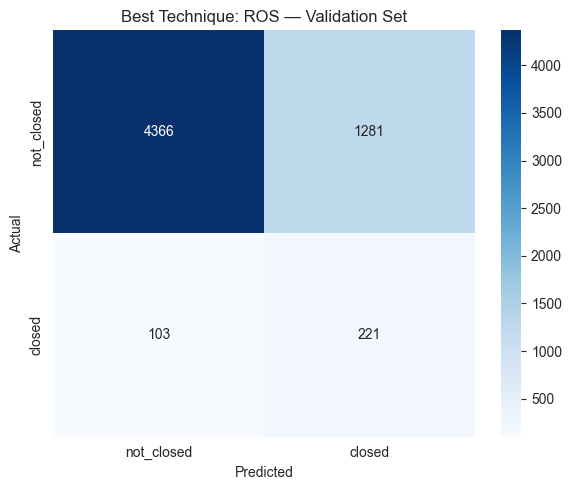

              precision    recall  f1-score   support

  not_closed       0.98      0.77      0.86      5647
      closed       0.15      0.68      0.24       324

    accuracy                           0.77      5971
   macro avg       0.56      0.73      0.55      5971
weighted avg       0.93      0.77      0.83      5971



In [20]:
if best_name in techniques:
    X_res_b, y_res_b = techniques[best_name].fit_resample(X_train, y_train)
    best_final_model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, objective='binary:logistic',
        eval_metric='logloss', verbosity=0
    )
    best_final_model.fit(X_res_b, y_res_b)
elif 'Class Weights' in best_name:
    best_final_model = model_weighted
else:
    best_final_model = baseline_model

y_pred_best_val = best_final_model.predict(X_val)
plot_confusion_matrix(y_val, y_pred_best_val,
                      f'Best Technique: {best_name} — Validation Set')

print(classification_report(y_val, y_pred_best_val, target_names=STATUS_NAMES))

## Summary

| Output file | Description |
|-------------|-------------|
| `data/train_resampled_closed.csv` | Resampled binary training set for `PROBLEM="closed"` |
| `data/train_resampled_acquired.csv` | Resampled binary training set for `PROBLEM="acquired"` |
| `data/val_processed.csv` | Validation set — unchanged from `03_Preprocessing` |
| `data/test_processed.csv` | Test set — unchanged from `03_Preprocessing` |

**Next step → `07_Feature_Selection_n_Modeling_Binary.ipynb`:** Set the same `PROBLEM` value, load the matching resampled CSV, and run feature selection and modeling.